In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
data = pd.read_csv('mera.csv')

feature_cols = [
    'curr_ann_amt', 'days_tenure', 'age_in_years', 'income', 'has_children',
    'length_of_residence', 'marital_status', 'home_owner', 'college_degree', 'good_credit'
]
target_col = 'Churn'

df = data[feature_cols + [target_col]].dropna()


C:\Users\animi\AppData\Local\Temp\ipykernel_25044\1330828172.py:1: DtypeWarning: Columns (24,25,26,27,31,33,34,38,39,43) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('mera.csv')


In [13]:
categorical_cols = ['marital_status', 'home_owner', 'college_degree', 'good_credit', 'has_children']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [14]:
X = df[feature_cols].copy()
y = df[target_col].copy()


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
train_df = pd.concat([X_train, y_train], axis=1)
majority = train_df[train_df[target_col] == 0]
minority = train_df[train_df[target_col] == 1]

In [17]:
minority_upsampled = resample(minority,
                              replace=True,
                              n_samples=len(majority),
                              random_state=42)

In [18]:
train_balanced = pd.concat([majority, minority_upsampled])
train_balanced = train_balanced.sample(frac=1, random_state=42)

In [19]:
X_train_bal = train_balanced[feature_cols]
y_train_bal = train_balanced[target_col]

scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test.fillna(X_test.median()))

In [21]:
rf_clf = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_clf.fit(X_train_bal_scaled, y_train_bal)
rf_preds = rf_clf.predict(X_test_scaled)
print(f'Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}')

KeyboardInterrupt: 

In [ ]:
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train_bal_scaled, y_train_bal)
xgb_preds = xgb_clf.predict(X_test_scaled)
print(f'XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}')

c:\Users\animi\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:24:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8723


C:\Users\animi\AppData\Local\Temp\ipykernel_24176\3562433840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_imp.values, y=rf_imp.index, palette='viridis')


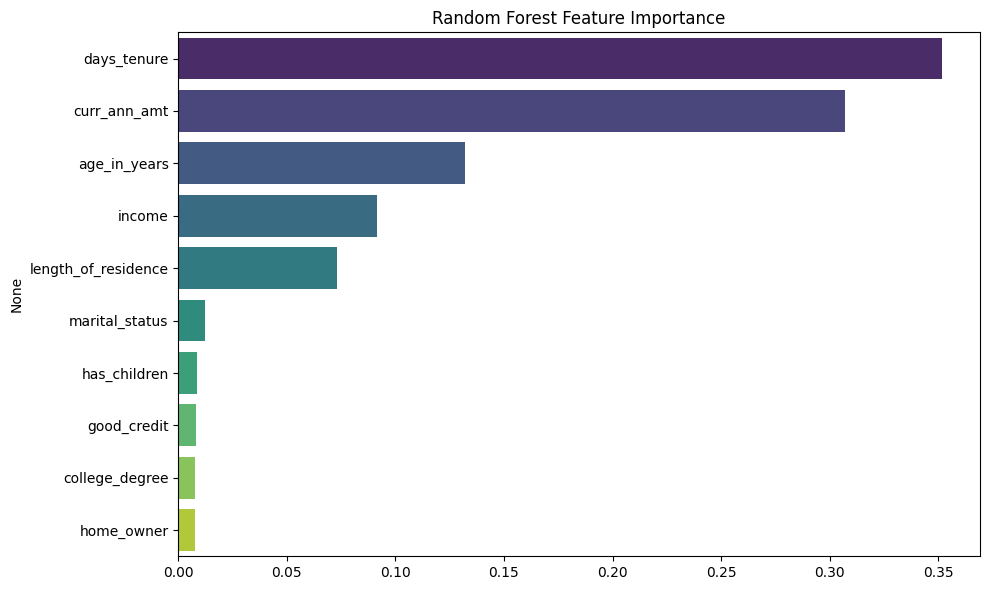

In [ ]:
rf_imp = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=rf_imp.values, y=rf_imp.index, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

C:\Users\animi\AppData\Local\Temp\ipykernel_24176\2985080265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_imp.values, y=xgb_imp.index, palette='coolwarm')


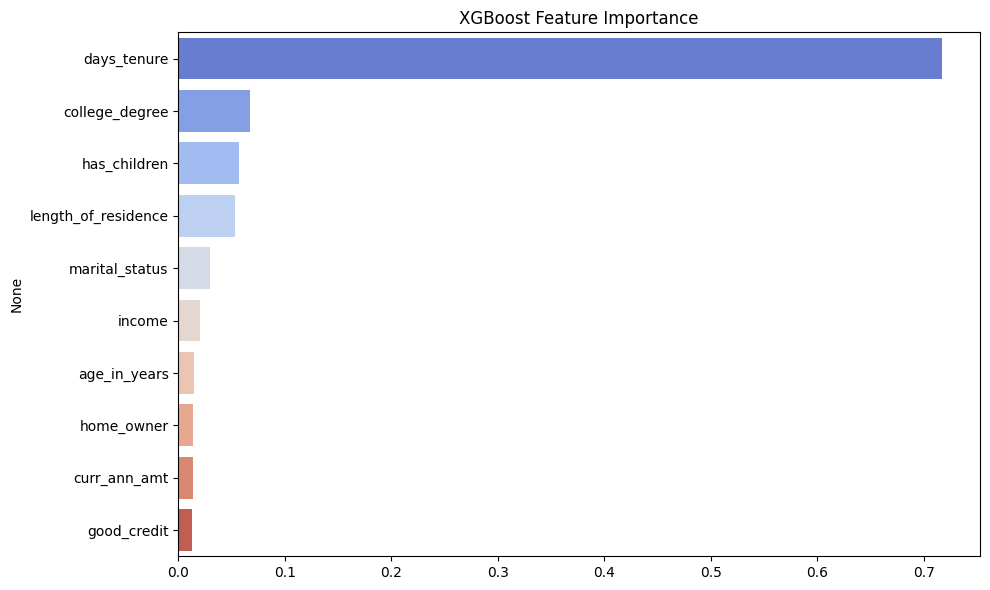

In [ ]:
xgb_imp = pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=xgb_imp.values, y=xgb_imp.index, palette='coolwarm')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
import shap

print("Calculating SHAP values for Random Forest...")
rf_explainer = shap.TreeExplainer(rf_clf)
rf_shap_values = rf_explainer.shap_values(X_test_scaled)

print("Calculating SHAP values for XGBoost...")
xgb_explainer = shap.TreeExplainer(xgb_clf)
xgb_shap_values = xgb_explainer.shap_values(X_test_scaled)

# Global explanation with summary plots
print("Displaying SHAP summary plot for Random Forest...")
shap.summary_plot(rf_shap_values[1], X_test, feature_names=feature_cols, show=True)

print("Displaying SHAP summary plot for XGBoost...")
shap.summary_plot(xgb_shap_values, X_test, feature_names=feature_cols, show=True)

# Dependence plots for most important features
most_important_rf = list(pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False).index[:3])
most_important_xgb = list(pd.Series(xgb_clf.feature_importances_, index=feature_cols).sort_values(ascending=False).index[:3])

for feat in most_important_rf:
    print(f"RF SHAP Dependence Plot for {feat}")
    shap.dependence_plot(feat, rf_shap_values[1], X_test, feature_names=feature_cols)

for feat in most_important_xgb:
    print(f"XGB SHAP Dependence Plot for {feat}")
    shap.dependence_plot(feat, xgb_shap_values, X_test, feature_names=feature_cols)

# Local explanation example (first test instance)
shap.initjs()
print("SHAP force plot for first test instance - Random Forest:")
shap.force_plot(rf_explainer.expected_value[1], rf_shap_values[1][0,:], X_test.iloc[0,:], feature_names=feature_cols, matplotlib=True)

print("SHAP force plot for first test instance - XGBoost:")
shap.force_plot(xgb_explainer.expected_value, xgb_shap_values[0], X_test.iloc[0,:], feature_names=feature_cols, matplotlib=True)


Calculating SHAP values for Random Forest...
